# Biodiversity forecasting benchmark with data inspection

This notebook builds and evaluates a **global machine learning approach for forecasting animal population time series** across multiple prepared biodiversity datasets.

It follows a structured pipeline:

### 1. Load and validate datasets
- Reads multiple prepared dataset variants  
- Ensures a consistent schema across all datasets  

### 2. Inspect the data before modeling
- Summarizes dataset characteristics (size, time span, population scale)  
- Analyzes the number and length of time series  
- Visualizes distributions of population values  
- Assesses whether the data is suitable for time-series forecasting  

### 3. Transform the data into a modeling format
- Converts wide-format time series into long format  
- Defines individual time series using a `series_id`  
- Creates lag-based and trend-based features  
- Applies a log transformation to the target variable  

### 4. Train forecasting models
- Uses a global modeling approach across all species and locations  
- Trains and tunes three models:
  - Ridge Regression  
  - Random Forest  
  - XGBoost  
- Uses time-based validation (train on past, test on future)  

### 5. Evaluate model performance
- Computes multiple metrics (MAE, RMSE, NMAE, WAPE, sMAPE)  
- Compares models across datasets  
- Identifies best-performing model–dataset combinations  

### 6. Analyze feature importance
- Uses permutation importance to understand which features drive predictions  
- Evaluates the role of lag features, trends, and contextual variables  

### 7. Support decision-making for the next steps
- Identifies the most suitable dataset for forecasting  
- Identifies the most effective model  
- Provides a foundation for building a forecasting system and dashboard  

---

## Overall goal

The notebook is designed to determine:

> Which data preparation strategy and which model provide the most reliable foundation  
> for forecasting biodiversity population trends.

It serves as the transition from **data exploration → model selection → forecasting system design**.

## 1. Imports and settings

In [23]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

DATA_DIR = Path("../data/interim")
DATASET_FILES = sorted(DATA_DIR.rglob("lpd_*.csv"))
DATASET_FILES = [file for file in DATASET_FILES if file.name != "lpd_master_initial.csv"]

N_LAGS = 4
TEST_YEARS = 5

print(f"Found {len(DATASET_FILES)} datasets:\n")
for file in DATASET_FILES:
    print("-", file.relative_to(DATA_DIR))

Found 10 datasets:

- balanced_forecasting\lpd_all_balanced_last2015_unitsusable_global_zeroskeep.csv
- balanced_forecasting\lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep.csv
- broad_exploration\lpd_all_loose_last2010_unitsall_global_zeroskeep.csv
- broad_exploration\lpd_terrestrial_loose_last2010_unitsall_global_zeroskeep.csv
- geographic_subsets\lpd_terrestrial_balanced_last2015_unitsusable_strongcountries_zeroskeep.csv
- geographic_subsets\lpd_terrestrial_balanced_last2015_unitsusable_top10countries_zeroskeep.csv
- risk_decline\lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep_risk.csv
- risk_decline\lpd_terrestrial_loose_last2015_unitsall_global_zeroskeep_risk.csv
- strict_forecasting\lpd_terrestrial_strict_last2020_unitsdirect_global_zeros_not_heavy.csv
- strict_forecasting\lpd_terrestrial_strict_last2020_unitsusable_global_zeroskeep.csv


## 2. Validate that all datasets use the same columns

In [24]:
column_map = {}
for file in DATASET_FILES:
    df = pd.read_csv(file, nrows=5)
    column_map[file.name] = list(df.columns)

reference_name = list(column_map.keys())[0]
reference_columns = column_map[reference_name]
reference_columns_set = set(reference_columns)

all_same = all(cols == reference_columns for cols in column_map.values())

print("All datasets use the same columns:", all_same)
print("Number of columns:", len(reference_columns))

if not all_same:
    for name, cols in column_map.items():
        if cols != reference_columns:
            print("\nDataset with different columns:", name)
            print("Only in this dataset:", sorted(set(cols) - set(reference_columns)))
            print("Missing from this dataset:", sorted(set(reference_columns) - set(cols)))

All datasets use the same columns: True
Number of columns: 126


**Result summary:**  
The benchmark assumes a shared schema across datasets.  
Because the columns are the same, one modeling pipeline can be reused consistently across all prepared dataset variants.


## 3. Define forecasting-relevant columns

In [25]:
year_columns = [col for col in reference_columns if str(col).isdigit()]

static_numeric_features = ["latitude", "longitude"]

static_categorical_features = [
    "class",
    "family",
    "ipbes_subregion",
    "system_group",
    "t_realm",
    "t_biome",
    "units"
]

identifier_columns = ["id", "binomial", "common_name", "location", "country"]

leakage_columns = [
    "n_obs",
    "first_obs_year",
    "last_obs_year",
    "time_span",
    "n_gaps",
    "max_gap",
    "continuity_ratio",
    "zero_count",
    "zero_share",
    "years_since_last_obs"
]

static_numeric_features = [c for c in static_numeric_features if c in reference_columns_set]
static_categorical_features = [c for c in static_categorical_features if c in reference_columns_set]
identifier_columns = [c for c in identifier_columns if c in reference_columns_set]
leakage_columns = [c for c in leakage_columns if c in reference_columns_set]

print("Number of year columns:", len(year_columns))
print("Example year columns:", year_columns[:10])

print("\nNumeric predictors:", static_numeric_features)
print("\nCategorical predictors:", static_categorical_features)
print("\nIdentifier columns:", identifier_columns)
print("\nLeakage columns:", leakage_columns)

Number of year columns: 71
Example year columns: ['1950', '1951', '1952', '1953', '1954', '1955', '1956', '1957', '1958', '1959']

Numeric predictors: ['latitude', 'longitude']

Categorical predictors: ['class', 'family', 'ipbes_subregion', 'system_group', 't_realm', 't_biome', 'units']

Identifier columns: ['id', 'binomial', 'common_name', 'location', 'country']

Leakage columns: ['n_obs', 'first_obs_year', 'last_obs_year', 'time_span', 'n_gaps', 'max_gap', 'continuity_ratio', 'zero_count', 'zero_share', 'years_since_last_obs']


**Result summary:**  
The forecasting setup uses lagged population values plus a compact set of static predictors.  
Geographic, ecological, taxonomic, and unit-related columns are included as context, while full-series summary columns are excluded to avoid leakage.


## 4. Helper functions

In [27]:
def build_series_id(df):
    """
    Construct a unique identifier for each time series.
    """
    parts = []

    if "common_name" in df.columns:
        parts.append(df["common_name"].astype(str))
    elif "binomial" in df.columns:
        parts.append(df["binomial"].astype(str))

    if "country" in df.columns:
        parts.append(df["country"].astype(str))

    if len(parts) == 0:
        return pd.Series(np.arange(len(df)).astype(str), index=df.index)

    series_id = parts[0]
    for p in parts[1:]:
        series_id = series_id + "|" + p

    return series_id


def wide_to_long(df):
    """
    Convert wide-format biodiversity data into long-format time series.

    The original dataset contains one column per year. This function reshapes
    the data into a long format suitable for time-series modeling and feature
    engineering.
    """
    id_columns = [col for col in df.columns if col not in year_columns]

    long_df = df.melt(
        id_vars=id_columns,
        value_vars=year_columns,
        var_name="Year",
        value_name="Population"
    ).dropna(subset=["Population"]).copy()

    long_df["Year"] = long_df["Year"].astype(int)
    long_df["series_id"] = build_series_id(long_df)
    long_df["log_population"] = np.log1p(long_df["Population"])

    return long_df


def add_lag_features(long_df, n_lags=4):
    """
    Create lag-based and trend-based features for time-series forecasting.

    For each series_id, this function generates:
    - Lag features (previous observations)
    - Time gap features
    - Rolling statistics (mean, standard deviation)
    - Change-based features (difference and growth rate)
    """
    long_df = long_df.sort_values(["series_id", "Year"]).copy()
    grouped_pop = long_df.groupby("series_id")["Population"]

    for lag in range(1, n_lags + 1):
        long_df[f"lag_{lag}"] = grouped_pop.shift(lag)

    long_df["prev_year"] = long_df.groupby("series_id")["Year"].shift(1)
    long_df["year_gap_from_prev"] = long_df["Year"] - long_df["prev_year"]

    long_df["rolling_mean_3"] = (
        grouped_pop.shift(1)
        .rolling(3)
        .mean()
        .reset_index(level=0, drop=True)
    )

    long_df["rolling_std_3"] = (
        grouped_pop.shift(1)
        .rolling(3)
        .std()
        .reset_index(level=0, drop=True)
    )

    long_df["population_difference"] = long_df["lag_1"] - long_df["lag_2"]

    long_df["population_growth_rate"] = (
        (long_df["lag_1"] - long_df["lag_2"]) /
        long_df["lag_2"].replace(0, np.nan)
    )
    long_df["population_growth_rate"] = long_df["population_growth_rate"].replace(
        [np.inf, -np.inf], np.nan
    )

    needed = [f"lag_{lag}" for lag in range(1, n_lags + 1)]
    long_df = long_df.dropna(subset=needed).copy()

    return long_df


def temporal_split(df, test_years=5):
    """
    Split the dataset into training and testing sets based on time.

    The most recent `test_years` are used as the test set, while all earlier
    years are used for training.
    """
    years = sorted(df["Year"].unique())
    test_year_values = years[-test_years:]

    train_df = df[df["Year"] < min(test_year_values)].copy().reset_index(drop=True)
    test_df = df[df["Year"].isin(test_year_values)].copy().reset_index(drop=True)

    return train_df, test_df, test_year_values


def make_preprocessor():
    """
    Create a preprocessing pipeline for numeric and categorical features.

    - Numeric features are imputed (median) and standardized
    - Categorical features are imputed (most frequent) and one-hot encoded
    """
    numeric_features = (
        ["Year"]
        + [f"lag_{i}" for i in range(1, N_LAGS + 1)]
        + [
            "year_gap_from_prev",
            "rolling_mean_3",
            "rolling_std_3",
            "population_difference",
            "population_growth_rate",
        ]
        + static_numeric_features
    )

    categorical_features = static_categorical_features

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), numeric_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), categorical_features)
        ]
    )

    return preprocessor, numeric_features, categorical_features


def evaluate(y_true, y_pred):
    """
    Compute multiple evaluation metrics for regression performance.

    Metrics:
    - MAE: Mean Absolute Error
    - RMSE: Root Mean Squared Error
    - NMAE: Normalized MAE
    - WAPE: Weighted Absolute Percentage Error
    - sMAPE: Symmetric Mean Absolute Percentage Error
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mean_abs_true = np.mean(np.abs(y_true))
    nmae = mae / mean_abs_true if mean_abs_true != 0 else np.nan

    denom = np.sum(np.abs(y_true))
    wape = np.sum(np.abs(y_true - y_pred)) / denom if denom != 0 else np.nan

    smape_denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    valid = smape_denom != 0
    smape = np.mean(
        np.abs(y_true[valid] - y_pred[valid]) / smape_denom[valid]
    ) if np.any(valid) else np.nan

    return {"MAE": mae, "RMSE": rmse, "NMAE": nmae, "WAPE": wape, "sMAPE": smape}


def get_permutation_importance_df(estimator, X_test, y_test, feature_columns):
    """
    Compute permutation feature importance for a trained model.

    The importance measures how much model performance decreases when a feature
    is randomly shuffled.
    """
    result = permutation_importance(
        estimator,
        X_test,
        y_test,
        n_repeats=5,
        random_state=42,
        n_jobs=-1
    )

    importance_df = pd.DataFrame({
        "feature": feature_columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    }).sort_values("importance_mean", ascending=False)

    return importance_df


def inspect_dataset(file_path):
    """
    Perform basic exploratory analysis for a dataset.

    Computes:
    - Dataset size (wide and long)
    - Number of unique time series
    - Time range
    - Population statistics
    - Distribution of series lengths
    """
    df = pd.read_csv(file_path)
    long_df = wide_to_long(df)

    summary = {
        "dataset": file_path.name,
        "group": file_path.parent.name,
        "rows_wide": len(df),
        "rows_long": len(long_df),
        "unique_series": long_df["series_id"].nunique(),
        "year_min": int(long_df["Year"].min()),
        "year_max": int(long_df["Year"].max()),
        "population_min": float(long_df["Population"].min()),
        "population_median": float(long_df["Population"].median()),
        "population_max": float(long_df["Population"].max())
    }

    series_lengths = long_df.groupby("series_id")["Year"].count()

    summary["series_length_median"] = float(series_lengths.median())
    summary["series_length_mean"] = float(series_lengths.mean())
    summary["series_length_min"] = int(series_lengths.min())
    summary["series_length_max"] = int(series_lengths.max())

    return df, long_df, pd.DataFrame([summary]), series_lengths


def run_one_dataset(file_path):
    """
    Train and evaluate multiple forecasting models on a single dataset.

    Pipeline:
    - Load and transform data
    - Create lag features
    - Split into train/test sets
    - Train and tune models (Ridge, RandomForest, XGBoost)
    - Evaluate performance on original population scale
    - Compute permutation importance
    """
    df = pd.read_csv(file_path)
    long_df = wide_to_long(df)
    long_df = add_lag_features(long_df, n_lags=N_LAGS)

    preprocessor, numeric_features, categorical_features = make_preprocessor()
    feature_columns = numeric_features + categorical_features

    model_columns = []
    for col in ["Year", "Population", "log_population"] + feature_columns:
        if col not in model_columns:
            model_columns.append(col)

    model_df = long_df[model_columns].copy()

    train_df, test_df, test_year_values = temporal_split(model_df, test_years=TEST_YEARS)

    X_train = train_df[feature_columns]
    y_train = train_df["log_population"]
    X_test = test_df[feature_columns]
    y_test_log = test_df["log_population"]
    y_test = test_df["Population"]

    cv_year_cut = sorted(train_df["Year"].unique())
    split_year = cv_year_cut[int(len(cv_year_cut) * 0.8)]

    cv_train_idx = np.where(train_df["Year"] <= split_year)[0]
    cv_val_idx = np.where(train_df["Year"] > split_year)[0]
    cv_splits = [(cv_train_idx, cv_val_idx)]

    models = {
        "Ridge": (
            Pipeline([
                ("prep", preprocessor),
                ("model", Ridge())
            ]),
            {"model__alpha": [0.1, 1.0, 10.0]}
        ),
        "RandomForest": (
            Pipeline([
                ("prep", preprocessor),
                ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
            ]),
            {"model__n_estimators": [200], "model__max_depth": [8, None]}
        ),
        "XGBoost": (
            Pipeline([
                ("prep", preprocessor),
                ("model", XGBRegressor(
                    random_state=42,
                    objective="reg:squarederror",
                    n_estimators=200,
                    tree_method="hist",
                    n_jobs=-1
                ))
            ]),
            {"model__max_depth": [4, 8], "model__learning_rate": [0.05, 0.1]}
        )
    }

    results = []
    importance_tables = {}

    for model_name, (pipeline, param_grid) in models.items():
        grid = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring="neg_mean_absolute_error",
            cv=cv_splits,
            n_jobs=-1,
            refit=True
        )
        grid.fit(X_train, y_train)

        preds_log = grid.best_estimator_.predict(X_test)
        preds = np.expm1(preds_log)
        preds = np.clip(preds, a_min=0, a_max=None)

        metrics = evaluate(y_test.to_numpy(), preds)

        results.append({
            "dataset": file_path.name,
            "dataset_group": file_path.parent.name,
            "model": model_name,
            "best_params": str(grid.best_params_),
            "MAE": metrics["MAE"],
            "RMSE": metrics["RMSE"],
            "NMAE": metrics["NMAE"],
            "WAPE": metrics["WAPE"],
            "sMAPE": metrics["sMAPE"],
            "train_rows": len(train_df),
            "test_rows": len(test_df),
            "test_years": ", ".join(map(str, test_year_values))
        })

        imp_df = get_permutation_importance_df(
            grid.best_estimator_, X_test, y_test_log, feature_columns
        )

        imp_df["dataset"] = file_path.name
        imp_df["dataset_group"] = file_path.parent.name
        imp_df["model"] = model_name

        importance_tables[model_name] = imp_df

    return pd.DataFrame(results), importance_tables

## 5. Inspect transformed the data before building models

In [28]:
inspection_summaries = []
series_length_tables = []

for file_path in DATASET_FILES:
    _, long_df_preview, summary_df, series_lengths = inspect_dataset(file_path)
    inspection_summaries.append(summary_df)
    series_length_tables.append(
        pd.DataFrame({
            "dataset": file_path.name,
            "series_length": series_lengths.values
        })
    )

inspection_df = pd.concat(inspection_summaries, ignore_index=True)
inspection_df

,dataset,group,rows_wide,rows_long,unique_series,year_min,year_max,population_min,population_median,population_max,series_length_median,series_length_mean,series_length_min,series_length_max
0,lpd_all_balanced_last2015_unitsusable_global_z...,balanced_forecasting,1524,35987,192,1960,2020,0.0,2.00,1.479582e+06,32.0,187.432292,15,2789
1,lpd_terrestrial_balanced_last2015_unitsusable_...,balanced_forecasting,366,7763,50,1977,2020,0.0,2.00,2.288670e+05,22.5,155.260000,15,2789
2,lpd_all_loose_last2010_unitsall_global_zeroske...,broad_exploration,8278,203762,1852,1950,2020,0.0,1.97,2.500000e+15,40.0,110.022678,10,14031
3,lpd_terrestrial_loose_last2010_unitsall_global...,broad_exploration,2809,90600,845,1950,2020,0.0,2.25,1.015962e+06,40.0,107.218935,10,2789
4,lpd_terrestrial_balanced_last2015_unitsusable_...,geographic_subsets,362,7676,46,1977,2020,0.0,2.00,2.288670e+05,23.0,166.869565,15,2789
5,lpd_terrestrial_balanced_last2015_unitsusable_...,geographic_subsets,252,5738,31,1977,2020,0.0,1.00,2.288670e+05,22.0,185.096774,15,2789
6,lpd_terrestrial_balanced_last2015_unitsusable_...,risk_decline,366,7763,50,1977,2020,0.0,2.00,2.288670e+05,22.5,155.260000,15,2789
7,lpd_terrestrial_loose_last2015_unitsall_global...,risk_decline,1093,22823,417,1958,2020,0.0,9.00,2.288670e+05,30.0,54.731415,10,2789
8,lpd_terrestrial_strict_last2020_unitsdirect_gl...,strict_forecasting,34,955,10,1980,2020,0.0,4.00,7.510000e+02,39.5,95.500000,20,579
9,lpd_terrestrial_strict_last2020_unitsusable_gl...,strict_forecasting,49,1349,10,1980,2020,0.0,3.00,7.510000e+02,45.0,134.900000,20,953


In [6]:
inspection_df.sort_values("series_length_median", ascending=False)

,dataset,group,rows_wide,rows_long,unique_series,year_min,year_max,population_min,population_median,population_max,series_length_median,series_length_mean,series_length_min,series_length_max
3,lpd_terrestrial_loose_last2010_unitsall_global...,broad_exploration,2809,90600,2355,1950,2020,0.0,2.25,1.015962e+06,42.0,38.471338,10,2789
9,lpd_terrestrial_strict_last2020_unitsusable_gl...,strict_forecasting,49,1349,15,1980,2020,0.0,3.00,7.510000e+02,36.0,89.933333,20,555
2,lpd_all_loose_last2010_unitsall_global_zeroske...,broad_exploration,8278,203762,5141,1950,2020,0.0,1.97,2.500000e+15,35.0,39.634701,10,2789
8,lpd_terrestrial_strict_last2020_unitsdirect_gl...,strict_forecasting,34,955,14,1980,2020,0.0,4.00,7.510000e+02,34.0,68.214286,20,371
5,lpd_terrestrial_balanced_last2015_unitsusable_...,geographic_subsets,252,5738,46,1977,2020,0.0,1.00,2.288670e+05,24.5,124.739130,15,2789
0,lpd_all_balanced_last2015_unitsusable_global_z...,balanced_forecasting,1524,35987,579,1960,2020,0.0,2.00,1.479582e+06,23.0,62.153713,15,2789
1,lpd_terrestrial_balanced_last2015_unitsusable_...,balanced_forecasting,366,7763,160,1977,2020,0.0,2.00,2.288670e+05,18.0,48.518750,15,2789
4,lpd_terrestrial_balanced_last2015_unitsusable_...,geographic_subsets,362,7676,156,1977,2020,0.0,2.00,2.288670e+05,18.0,49.205128,15,2789
7,lpd_terrestrial_loose_last2015_unitsall_global...,risk_decline,1093,22823,669,1958,2020,0.0,9.00,2.288670e+05,18.0,34.115097,10,2789
6,lpd_terrestrial_balanced_last2015_unitsusable_...,risk_decline,366,7763,160,1977,2020,0.0,2.00,2.288670e+05,18.0,48.518750,15,2789


**Result summary:**  
This inspection step shows how the prepared datasets differ before any model is trained.  
The most important quantities here are the number of unique series, the year range, the population scale, and the typical series length.  
These characteristics strongly influence how easy or difficult forecasting will be.


## 6. Inspect one example dataset in more detail

In [29]:
example_file = DATASET_FILES[0]
example_df, example_long_df, example_summary, example_series_lengths = inspect_dataset(example_file)

print("Example dataset:", example_file.relative_to(DATA_DIR))
display(example_summary)
display(example_df.head())
display(example_long_df.head())

Example dataset: balanced_forecasting\lpd_all_balanced_last2015_unitsusable_global_zeroskeep.csv


,dataset,group,rows_wide,rows_long,unique_series,year_min,year_max,population_min,population_median,population_max,series_length_median,series_length_mean,series_length_min,series_length_max
0,lpd_all_balanced_last2015_unitsusable_global_z...,balanced_forecasting,1524,35987,192,1960,2020,0.0,2.0,1479582.0,32.0,187.432292,15,2789


,id,binomial,replicate,included_in_lpr2024,citation,class,order,family,genus,species,...,has_binomial,has_class,has_order,has_family,has_genus,has_species,has_taxonomy_hierarchy,unit_category,unit_usable,system_group
0,826,Alosa_sapidissima,0,1,"US Fish and Wildlife Service (2006). ""Historic...",Actinopteri,Clupeiformes,Clupeidae,Alosa,sapidissima,...,True,True,True,True,True,True,True,direct_count,True,freshwater
1,879,Salmo_salar,0,1,"US Fish and Wildlife Service (2006). ""Historic...",Actinopteri,Salmoniformes,Salmonidae,Salmo,salar,...,True,True,True,True,True,True,True,direct_count,True,freshwater
2,4539,Emydoidea_blandingii,0,1,"Standing, K. L., T. B. Herman, et al. (2000). ...",Reptilia,Testudines,Emydidae,Emydoidea,blandingii,...,True,True,True,True,True,True,True,direct_count,True,freshwater
3,5466,Caretta_caretta,1,0,"Canbolat, A. F. (2004). ""A review of sea turtl...",Reptilia,Testudines,Cheloniidae,Caretta,caretta,...,True,True,True,True,True,True,True,direct_count,True,marine
4,5503,Caretta_caretta,0,1,"Ilgaz, C., O. T. rkozan, et al. (2007). ""Popul...",Reptilia,Testudines,Cheloniidae,Caretta,caretta,...,True,True,True,True,True,True,True,direct_count,True,marine


,id,binomial,replicate,included_in_lpr2024,citation,class,order,family,genus,species,...,has_genus,has_species,has_taxonomy_hierarchy,unit_category,unit_usable,system_group,Year,Population,series_id,log_population
15441,27913,Phoca_vitulina,0,1,CBS et al. (2020) Gewone en grijze zeehond in ...,Mammalia,Carnivora,Phocidae,Phoca,vitulina,...,True,True,True,direct_count,True,marine,1960,1250.0,Harbour seal|netherlands,7.131699
15443,27915,Phoca_vitulina,0,1,CBS et al. (2020) Gewone en grijze zeehond in ...,Mammalia,Carnivora,Phocidae,Phoca,vitulina,...,True,True,True,direct_count,True,marine,1960,350.0,Harbour seal|netherlands,5.860786
16965,27913,Phoca_vitulina,0,1,CBS et al. (2020) Gewone en grijze zeehond in ...,Mammalia,Carnivora,Phocidae,Phoca,vitulina,...,True,True,True,direct_count,True,marine,1961,1250.0,Harbour seal|netherlands,7.131699
16967,27915,Phoca_vitulina,0,1,CBS et al. (2020) Gewone en grijze zeehond in ...,Mammalia,Carnivora,Phocidae,Phoca,vitulina,...,True,True,True,direct_count,True,marine,1961,330.0,Harbour seal|netherlands,5.802118
18489,27913,Phoca_vitulina,0,1,CBS et al. (2020) Gewone en grijze zeehond in ...,Mammalia,Carnivora,Phocidae,Phoca,vitulina,...,True,True,True,direct_count,True,marine,1962,1375.0,Harbour seal|netherlands,7.226936


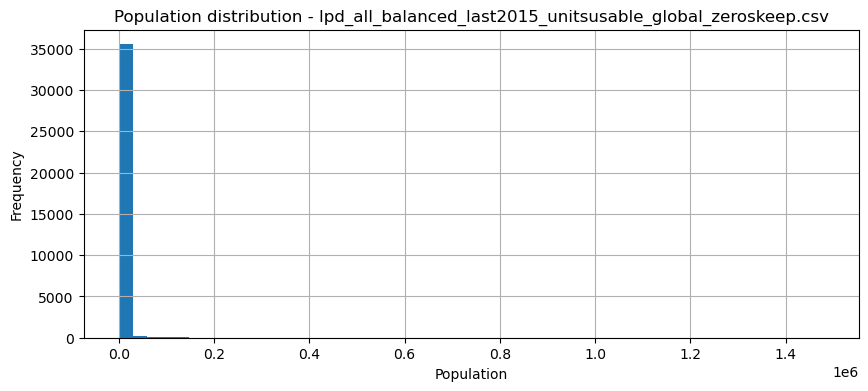

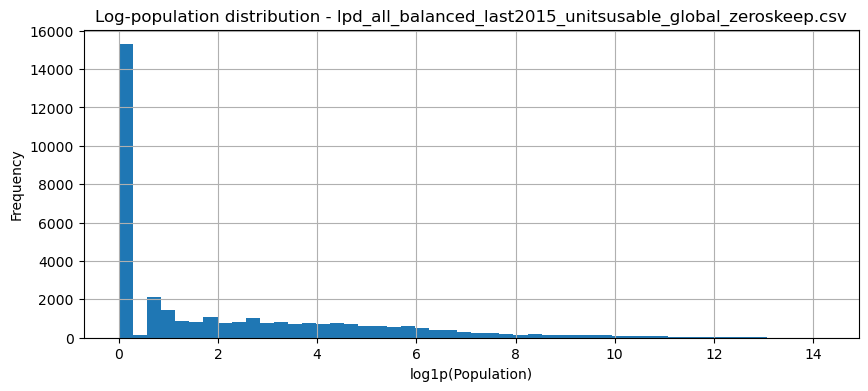

In [9]:
plt.figure(figsize=(10, 4))
example_long_df["Population"].hist(bins=50)
plt.title(f"Population distribution - {example_file.name}")
plt.xlabel("Population")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 4))
example_long_df["log_population"].hist(bins=50)
plt.title(f"Log-population distribution - {example_file.name}")
plt.xlabel("log1p(Population)")
plt.ylabel("Frequency")
plt.show()

**Result summary:**  
The raw population distribution is often highly skewed, while the log-transformed distribution is a little more compact.  
This is one reason why predicting `log_population` can make the learning problem more stable.

## 7. Why the target is transformed

This notebook predicts:

```python
log_population = np.log1p(population)
```

instead of raw population.

This transformation is useful because biodiversity populations can differ greatly in scale.  
For example, one series may contain values in the tens, while another may contain values in the thousands or millions.

The model is trained on the log scale, but evaluation is carried out on the **original population scale** after transforming predictions back with:

```python
np.expm1(preds_log)
```


**Summary:**  
Using a log-transformed target reduces the influence of extremely large populations during training.  
This usually improves stability and makes the models less dominated by a few very large series.


## 8. Why the added dynamic features may improve forecasting

The lag features capture short-term memory, but populations can also show short trends and instability.

The additional features serve different roles:

- `rolling_mean_3`: summarizes the recent level of the population
- `rolling_std_3`: captures short-term volatility
- `population_difference`: captures recent absolute change
- `population_growth_rate`: captures recent relative change

These features can help tree-based models because they provide trend and momentum information more directly than raw lags alone.


## 9. Why these models are suitable

### Ridge Regression
Ridge is a simple and interpretable baseline.

### Random Forest
Random Forest can model non-linear relationships and interactions between lag features and metadata.

### XGBoost
XGBoost is one of the strongest models for structured tabular data.

### Permutation importance
Permutation importance is used after training to estimate which predictors the model actually depends on.


## 10. Run the benchmark for all datasets

In [30]:
all_results = []
all_importance_tables = []

for file_path in DATASET_FILES:
    print("=" * 100)
    print("Running:", file_path.relative_to(DATA_DIR))

    result_df, importance_tables = run_one_dataset(file_path)
    display(result_df.sort_values("MAE"))

    all_results.append(result_df)

    for model_name, imp_df in importance_tables.items():
        all_importance_tables.append(imp_df)

results_df = pd.concat(all_results, ignore_index=True)
importance_df = pd.concat(all_importance_tables, ignore_index=True)

print("Finished.")

Running: balanced_forecasting\lpd_all_balanced_last2015_unitsusable_global_zeroskeep.csv


,dataset,dataset_group,model,best_params,MAE,RMSE,NMAE,WAPE,sMAPE,train_rows,test_rows,test_years
2,lpd_all_balanced_last2015_unitsusable_global_z...,balanced_forecasting,XGBoost,"{'model__learning_rate': 0.05, 'model__max_dep...",351.529925,5404.695649,0.333723,0.333723,1.503669,29679,5540,"2016, 2017, 2018, 2019, 2020"
1,lpd_all_balanced_last2015_unitsusable_global_z...,balanced_forecasting,RandomForest,"{'model__max_depth': None, 'model__n_estimator...",421.791040,7356.569070,0.400424,0.400424,1.496886,29679,5540,"2016, 2017, 2018, 2019, 2020"
0,lpd_all_balanced_last2015_unitsusable_global_z...,balanced_forecasting,Ridge,{'model__alpha': 0.1},787.645134,11683.230292,0.747745,0.747745,1.579951,29679,5540,"2016, 2017, 2018, 2019, 2020"


Running: balanced_forecasting\lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep.csv


,dataset,dataset_group,model,best_params,MAE,RMSE,NMAE,WAPE,sMAPE,train_rows,test_rows,test_years
2,lpd_terrestrial_balanced_last2015_unitsusable_...,balanced_forecasting,XGBoost,"{'model__learning_rate': 0.05, 'model__max_dep...",261.487735,981.745567,0.304222,0.304222,1.081114,6574,989,"2016, 2017, 2018, 2019, 2020"
1,lpd_terrestrial_balanced_last2015_unitsusable_...,balanced_forecasting,RandomForest,"{'model__max_depth': None, 'model__n_estimator...",317.240318,1674.272806,0.369086,0.369086,1.079004,6574,989,"2016, 2017, 2018, 2019, 2020"
0,lpd_terrestrial_balanced_last2015_unitsusable_...,balanced_forecasting,Ridge,{'model__alpha': 0.1},604.880405,4676.329714,0.703735,0.703735,1.220406,6574,989,"2016, 2017, 2018, 2019, 2020"


Running: broad_exploration\lpd_all_loose_last2010_unitsall_global_zeroskeep.csv


...

Running: strict_forecasting\lpd_terrestrial_strict_last2020_unitsdirect_global_zeros_not_heavy.csv


,dataset,dataset_group,model,best_params,MAE,RMSE,NMAE,WAPE,sMAPE,train_rows,test_rows,test_years
1,lpd_terrestrial_strict_last2020_unitsdirect_gl...,strict_forecasting,RandomForest,"{'model__max_depth': None, 'model__n_estimator...",7.513997,18.916417,0.151317,0.151317,0.712799,746,169,"2016, 2017, 2018, 2019, 2020"
2,lpd_terrestrial_strict_last2020_unitsdirect_gl...,strict_forecasting,XGBoost,"{'model__learning_rate': 0.1, 'model__max_dept...",8.787900,22.153368,0.176971,0.176971,0.780008,746,169,"2016, 2017, 2018, 2019, 2020"
0,lpd_terrestrial_strict_last2020_unitsdirect_gl...,strict_forecasting,Ridge,{'model__alpha': 0.1},42.786189,162.347777,0.861632,0.861632,0.775632,746,169,"2016, 2017, 2018, 2019, 2020"


Running: strict_forecasting\lpd_terrestrial_strict_last2020_unitsusable_global_zeroskeep.csv


,dataset,dataset_group,model,best_params,MAE,RMSE,NMAE,WAPE,sMAPE,train_rows,test_rows,test_years
1,lpd_terrestrial_strict_last2020_unitsusable_gl...,strict_forecasting,RandomForest,"{'model__max_depth': None, 'model__n_estimator...",5.418735,14.912705,0.156247,0.156247,0.907014,1065,244,"2016, 2017, 2018, 2019, 2020"
2,lpd_terrestrial_strict_last2020_unitsusable_gl...,strict_forecasting,XGBoost,"{'model__learning_rate': 0.05, 'model__max_dep...",6.312938,17.588107,0.182031,0.182031,0.915787,1065,244,"2016, 2017, 2018, 2019, 2020"
0,lpd_terrestrial_strict_last2020_unitsusable_gl...,strict_forecasting,Ridge,{'model__alpha': 1.0},20.144894,77.745626,0.580870,0.580870,0.990127,1065,244,"2016, 2017, 2018, 2019, 2020"


Finished.


**Result summary:**  
After this step, the notebook contains one performance table per dataset-model combination and one permutation-importance table per dataset-model combination.  
The models are trained on the log-transformed target, but performance is evaluated after converting predictions back to the original population scale.


## 11. Reflection on evaluation metrics

This notebook reports several metrics because no single metric tells the whole story.

- **MAE**: average absolute prediction error in the original scale
- **RMSE**: penalizes large mistakes more strongly
- **NMAE**: scale-adjusted (i.e. normalized) MAE
- **WAPE**: weighted absolute percentage error
- **sMAPE**: symmetric mean absolute percentage error

For cross-dataset comparison, the relative metrics are usually more informative than raw MAE or RMSE when scale differences exist.


**Summary:**  
The evaluation is intentionally multi-metric.  
Raw error metrics are useful for within-dataset interpretation, while relative metrics are more helpful when comparing differently scaled datasets.


## 12. Compare model performance

In [31]:
results_df.sort_values(["dataset", "MAE"]).reset_index(drop=True)

,dataset,dataset_group,model,best_params,MAE,RMSE,NMAE,WAPE,sMAPE,train_rows,test_rows,test_years
0,lpd_all_balanced_last2015_unitsusable_global_z...,balanced_forecasting,XGBoost,"{'model__learning_rate': 0.05, 'model__max_dep...",3.515299e+02,5.404696e+03,0.333723,0.333723,1.503669,29679,5540,"2016, 2017, 2018, 2019, 2020"
1,lpd_all_balanced_last2015_unitsusable_global_z...,balanced_forecasting,RandomForest,"{'model__max_depth': None, 'model__n_estimator...",4.217910e+02,7.356569e+03,0.400424,0.400424,1.496886,29679,5540,"2016, 2017, 2018, 2019, 2020"
2,lpd_all_balanced_last2015_unitsusable_global_z...,balanced_forecasting,Ridge,{'model__alpha': 0.1},7.876451e+02,1.168323e+04,0.747745,0.747745,1.579951,29679,5540,"2016, 2017, 2018, 2019, 2020"
3,lpd_all_loose_last2010_unitsall_global_zeroske...,broad_exploration,RandomForest,"{'model__max_depth': None, 'model__n_estimator...",4.441607e+10,6.129489e+12,0.972105,0.972105,1.415350,176344,20010,"2016, 2017, 2018, 2019, 2020"
4,lpd_all_loose_last2010_unitsall_global_zeroske...,broad_exploration,XGBoost,"{'model__learning_rate': 0.05, 'model__max_dep...",4.445651e+10,6.087699e+12,0.972990,0.972990,1.450400,176344,20010,"2016, 2017, 2018, 2019, 2020"
5,lpd_all_loose_last2010_unitsall_global_zeroske...,broad_exploration,Ridge,{'model__alpha': 0.1},1.058907e+14,1.497862e+16,2317.559296,2317.559296,1.492802,176344,20010,"2016, 2017, 2018, 2019, 2020"
6,lpd_terrestrial_balanced_last2015_unitsusable_...,balanced_forecasting,XGBoost,"{'model__learning_rate': 0.05, 'model__max_dep...",2.614877e+02,9.817456e+02,0.304222,0.304222,1.081114,6574,989,"2016, 2017, 2018, 2019, 2020"
7,lpd_terrestrial_balanced_last2015_unitsusable_...,balanced_forecasting,RandomForest,"{'model__max_depth': None, 'model__n_estimator...",3.172403e+02,1.674273e+03,0.369086,0.369086,1.079004,6574,989,"2016, 2017, 2018, 2019, 2020"
8,lpd_terrestrial_balanced_last2015_unitsusable_...,balanced_forecasting,Ridge,{'model__alpha': 0.1},6.048804e+02,4.676330e+03,0.703735,0.703735,1.220406,6574,989,"2016, 2017, 2018, 2019, 2020"
9,lpd_terrestrial_balanced_last2015_unitsusable_...,risk_decline,XGBoost,"{'model__learning_rate': 0.05, 'model__max_dep...",2.614877e+02,9.817456e+02,0.304222,0.304222,1.081114,6574,989,"2016, 2017, 2018, 2019, 2020"


In [32]:
mae_table = results_df.pivot(index="dataset", columns="model", values="MAE")
rmse_table = results_df.pivot(index="dataset", columns="model", values="RMSE")
nmae_table = results_df.pivot(index="dataset", columns="model", values="NMAE")
wape_table = results_df.pivot(index="dataset", columns="model", values="WAPE")
smape_table = results_df.pivot(index="dataset", columns="model", values="sMAPE")

display(mae_table)
display(rmse_table)
display(nmae_table)
display(wape_table)
display(smape_table)

model,RandomForest,Ridge,XGBoost
dataset,,,
lpd_all_balanced_last2015_unitsusable_global_zeroskeep.csv,4.217910e+02,7.876451e+02,3.515299e+02
lpd_all_loose_last2010_unitsall_global_zeroskeep.csv,4.441607e+10,1.058907e+14,4.445651e+10
lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep.csv,3.172403e+02,6.048804e+02,2.614877e+02
lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep_risk.csv,3.172403e+02,6.048804e+02,2.614877e+02
lpd_terrestrial_balanced_last2015_unitsusable_strongcountries_zeroskeep.csv,3.143958e+02,6.081434e+02,3.108052e+02
lpd_terrestrial_balanced_last2015_unitsusable_top10countries_zeroskeep.csv,1.005338e+02,1.339297e+02,9.198082e+01
lpd_terrestrial_loose_last2010_unitsall_global_zeroskeep.csv,1.068813e+02,2.720421e+02,1.256094e+02
lpd_terrestrial_loose_last2015_unitsall_global_zeroskeep_risk.csv,1.184117e+02,2.401674e+02,1.312586e+02
lpd_terrestrial_strict_last2020_unitsdirect_global_zeros_not_heavy.csv,7.513997e+00,4.278619e+01,8.787900e+00


model,RandomForest,Ridge,XGBoost
dataset,,,
lpd_all_balanced_last2015_unitsusable_global_zeroskeep.csv,7.356569e+03,1.168323e+04,5.404696e+03
lpd_all_loose_last2010_unitsall_global_zeroskeep.csv,6.129489e+12,1.497862e+16,6.087699e+12
lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep.csv,1.674273e+03,4.676330e+03,9.817456e+02
lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep_risk.csv,1.674273e+03,4.676330e+03,9.817456e+02
lpd_terrestrial_balanced_last2015_unitsusable_strongcountries_zeroskeep.csv,1.736677e+03,4.675249e+03,1.406422e+03
lpd_terrestrial_balanced_last2015_unitsusable_top10countries_zeroskeep.csv,1.672776e+03,1.850654e+03,1.293914e+03
lpd_terrestrial_loose_last2010_unitsall_global_zeroskeep.csv,7.718813e+02,3.018250e+03,1.101532e+03
lpd_terrestrial_loose_last2015_unitsall_global_zeroskeep_risk.csv,9.548494e+02,2.934264e+03,1.282517e+03
lpd_terrestrial_strict_last2020_unitsdirect_global_zeros_not_heavy.csv,1.891642e+01,1.623478e+02,2.215337e+01


model,RandomForest,Ridge,XGBoost
dataset,,,
lpd_all_balanced_last2015_unitsusable_global_zeroskeep.csv,0.400424,0.747745,0.333723
lpd_all_loose_last2010_unitsall_global_zeroskeep.csv,0.972105,2317.559296,0.972990
lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep.csv,0.369086,0.703735,0.304222
lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep_risk.csv,0.369086,0.703735,0.304222
lpd_terrestrial_balanced_last2015_unitsusable_strongcountries_zeroskeep.csv,0.364470,0.705003,0.360307
lpd_terrestrial_balanced_last2015_unitsusable_top10countries_zeroskeep.csv,0.165341,0.220265,0.151275
lpd_terrestrial_loose_last2010_unitsall_global_zeroskeep.csv,0.327818,0.834388,0.385260
lpd_terrestrial_loose_last2015_unitsall_global_zeroskeep_risk.csv,0.363184,0.736624,0.402587
lpd_terrestrial_strict_last2020_unitsdirect_global_zeros_not_heavy.csv,0.151317,0.861632,0.176971


model,RandomForest,Ridge,XGBoost
dataset,,,
lpd_all_balanced_last2015_unitsusable_global_zeroskeep.csv,0.400424,0.747745,0.333723
lpd_all_loose_last2010_unitsall_global_zeroskeep.csv,0.972105,2317.559296,0.972990
lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep.csv,0.369086,0.703735,0.304222
lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep_risk.csv,0.369086,0.703735,0.304222
lpd_terrestrial_balanced_last2015_unitsusable_strongcountries_zeroskeep.csv,0.364470,0.705003,0.360307
lpd_terrestrial_balanced_last2015_unitsusable_top10countries_zeroskeep.csv,0.165341,0.220265,0.151275
lpd_terrestrial_loose_last2010_unitsall_global_zeroskeep.csv,0.327818,0.834388,0.385260
lpd_terrestrial_loose_last2015_unitsall_global_zeroskeep_risk.csv,0.363184,0.736624,0.402587
lpd_terrestrial_strict_last2020_unitsdirect_global_zeros_not_heavy.csv,0.151317,0.861632,0.176971


model,RandomForest,Ridge,XGBoost
dataset,,,
lpd_all_balanced_last2015_unitsusable_global_zeroskeep.csv,1.496886,1.579951,1.503669
lpd_all_loose_last2010_unitsall_global_zeroskeep.csv,1.415350,1.492802,1.450400
lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep.csv,1.079004,1.220406,1.081114
lpd_terrestrial_balanced_last2015_unitsusable_global_zeroskeep_risk.csv,1.079004,1.220406,1.081114
lpd_terrestrial_balanced_last2015_unitsusable_strongcountries_zeroskeep.csv,1.081053,1.226498,1.110547
lpd_terrestrial_balanced_last2015_unitsusable_top10countries_zeroskeep.csv,1.259800,1.254428,1.282706
lpd_terrestrial_loose_last2010_unitsall_global_zeroskeep.csv,0.707906,1.002473,0.731794
lpd_terrestrial_loose_last2015_unitsall_global_zeroskeep_risk.csv,0.703285,0.936111,0.713205
lpd_terrestrial_strict_last2020_unitsdirect_global_zeros_not_heavy.csv,0.712799,0.775632,0.780008


**Result summary:**  
These tables compare the models within each dataset from several angles.  
MAE and RMSE show absolute error, while NMAE, WAPE, and sMAPE help compare datasets more fairly when the underlying population scales differ.


## 13. Overall model comparison

In [33]:
overall_results = (
    results_df.groupby("model")[["MAE", "RMSE", "NMAE", "WAPE", "sMAPE"]]
    .mean()
    .sort_values("NMAE")
)

overall_results

,MAE,RMSE,NMAE,WAPE,sMAPE
model,,,,,
XGBoost,4.445652e+09,6.087699e+11,0.357359,0.357359,1.065035
RandomForest,4.441607e+09,6.129489e+11,0.363908,0.363908,1.044210
Ridge,1.058907e+13,1.497862e+15,232.365329,232.365329,1.169883


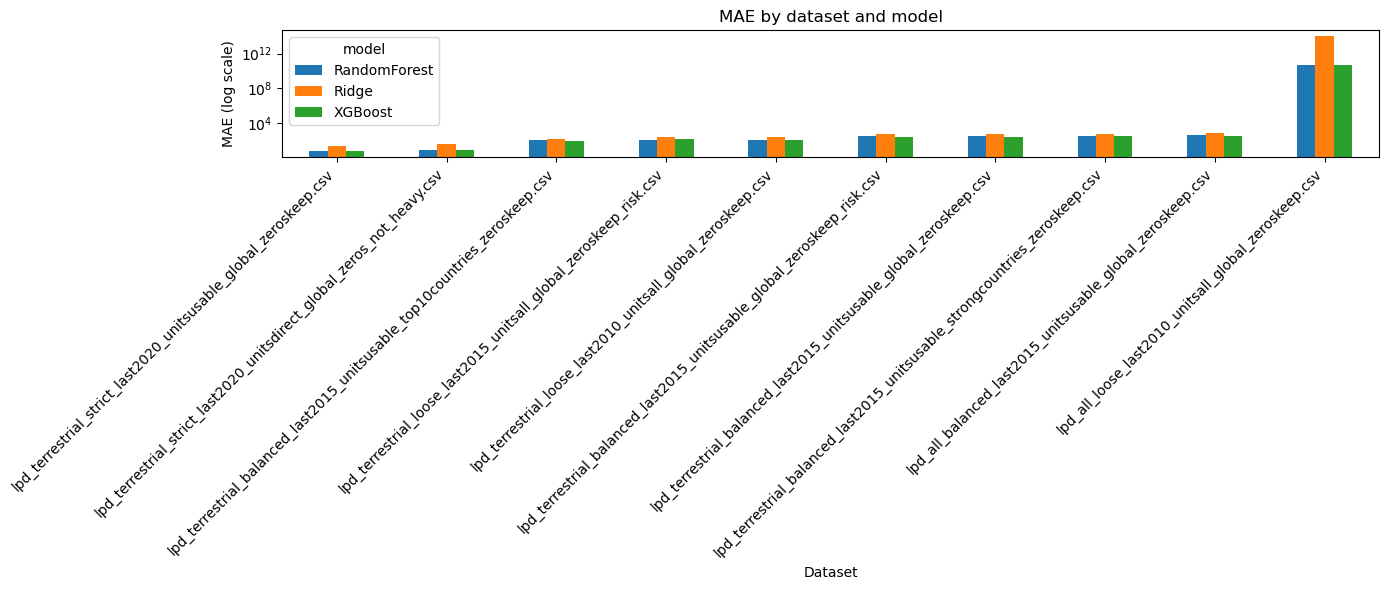

In [34]:
mae_table_sorted = mae_table.loc[mae_table.mean(axis=1).sort_values().index]

ax = mae_table_sorted.plot(kind="bar", figsize=(14, 6))
ax.set_title("MAE by dataset and model")
ax.set_ylabel("MAE (log scale)")
ax.set_xlabel("Dataset")
ax.set_yscale("log")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

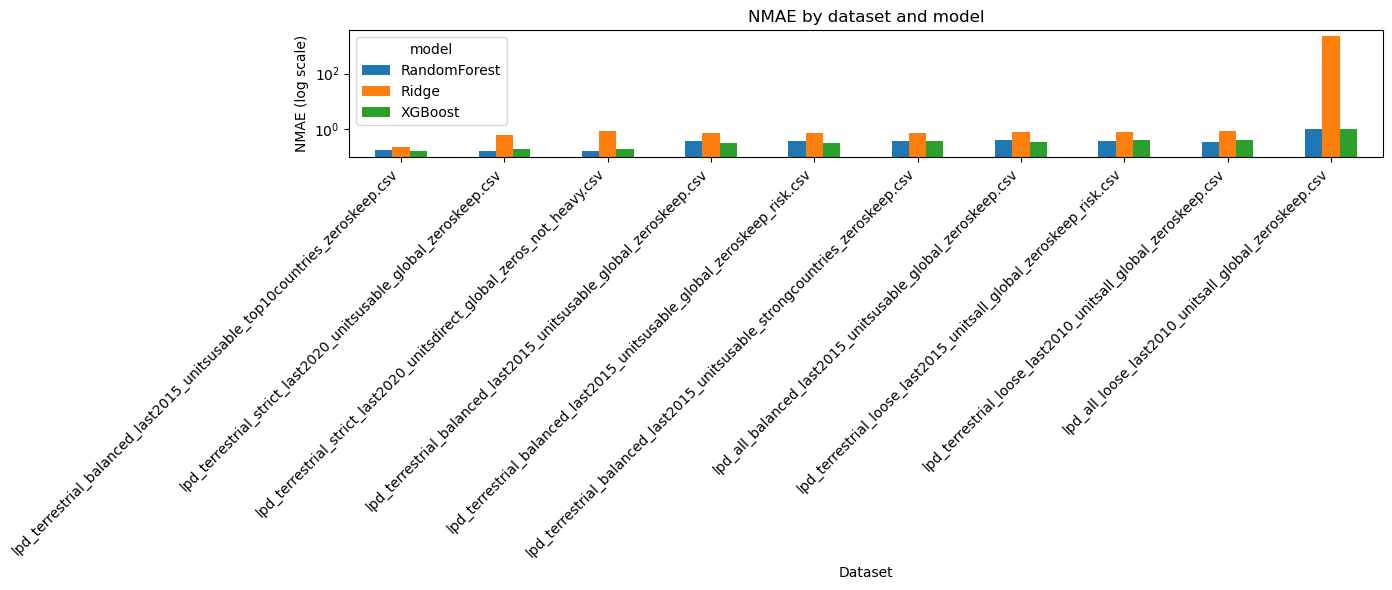

In [35]:
nmae_table_sorted = nmae_table.loc[nmae_table.mean(axis=1).sort_values().index]

ax = nmae_table_sorted.plot(kind="bar", figsize=(14, 6))
ax.set_title("NMAE by dataset and model")
ax.set_ylabel("NMAE (log scale)")
ax.set_xlabel("Dataset")
ax.set_yscale("log")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

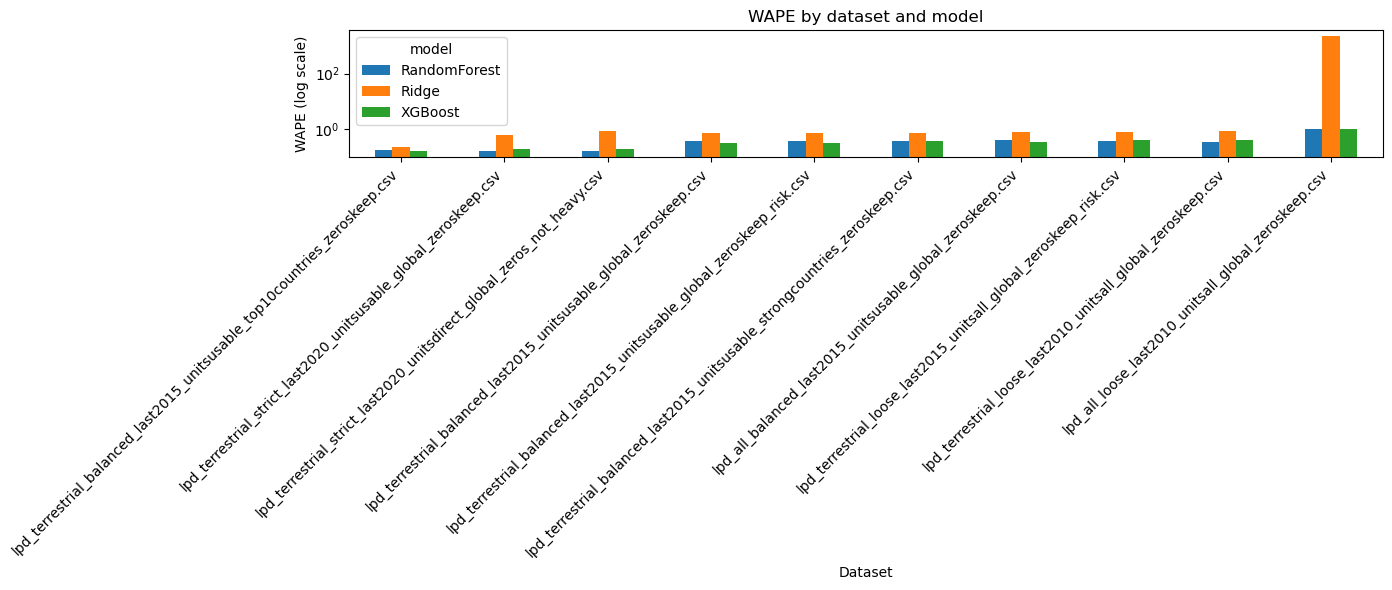

In [36]:
wape_table_sorted = wape_table.loc[wape_table.mean(axis=1).sort_values().index]

ax = wape_table_sorted.plot(kind="bar", figsize=(14, 6))
ax.set_title("WAPE by dataset and model")
ax.set_ylabel("WAPE (log scale)")
ax.set_xlabel("Dataset")
ax.set_yscale("log")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Result summary:**  
The overall comparison highlights whether one model performs consistently well across different preprocessing strategies.  
Because the datasets can still differ in scale and difficulty, the relative metrics usually provide the most trustworthy basis for ranking models.

The results indicate that XGBoost is the most suitable model, as it consistently achieves the lowest relative error (NMAE and WAPE) across datasets, demonstrating strong generalization across different population scales. While Random Forest performs similarly, XGBoost shows slightly more stable performance overall. 

Regarding dataset selection, the best-performing dataset (lpd_terrestrial_balanced_last2015_unitsusable_top10countries_zeroskeep.csv) achieves the lowest errors due to reduced noise and higher data consistency. However, it significantly narrows the geographical scope and limits generalizability.
Therefore, the second-tier datasets (lpd_terrestrial_strict_last2020_unitsdirect_global_zeros_not_heavy.csv and lpd_terrestrial_strict_last2020_unitsusable_global_zeroskeep.csv) represent the best trade-off between predictive performance and coverage. They maintain relatively low error levels while preserving a broader and more realistic representation of global biodiversity, making them more suitable for a practical forecasting application.

## 14. Permutation importance by model

Permutation importance is computed on held-out test data after each model has been trained and tuned.

A larger importance value means that shuffling the feature causes a larger deterioration in model performance.  
This helps identify whether predictive power comes mainly from lag features, rolling features, or broader ecological and taxonomic context.


In [37]:
importance_df.head()

,feature,importance_mean,importance_std,dataset,dataset_group,model
0,longitude,0.177798,0.005039,lpd_all_balanced_last2015_unitsusable_global_z...,balanced_forecasting,Ridge
1,family,0.114024,0.004378,lpd_all_balanced_last2015_unitsusable_global_z...,balanced_forecasting,Ridge
2,units,0.100387,0.005604,lpd_all_balanced_last2015_unitsusable_global_z...,balanced_forecasting,Ridge
3,class,0.087565,0.004797,lpd_all_balanced_last2015_unitsusable_global_z...,balanced_forecasting,Ridge
4,ipbes_subregion,0.066579,0.002195,lpd_all_balanced_last2015_unitsusable_global_z...,balanced_forecasting,Ridge


In [38]:
top_importance = (
    importance_df.groupby(["model", "feature"])["importance_mean"]
    .mean()
    .reset_index()
    .sort_values(["model", "importance_mean"], ascending=[True, False])
)

top_importance.groupby("model").head(10)

,model,feature,importance_mean
5,RandomForest,lag_2,0.446087
17,RandomForest,units,0.126241
8,RandomForest,latitude,0.068038
7,RandomForest,lag_4,0.066847
9,RandomForest,longitude,0.043651
3,RandomForest,ipbes_subregion,0.039582
14,RandomForest,system_group,0.032422
6,RandomForest,lag_3,0.031628
4,RandomForest,lag_1,0.026651
1,RandomForest,class,0.024081


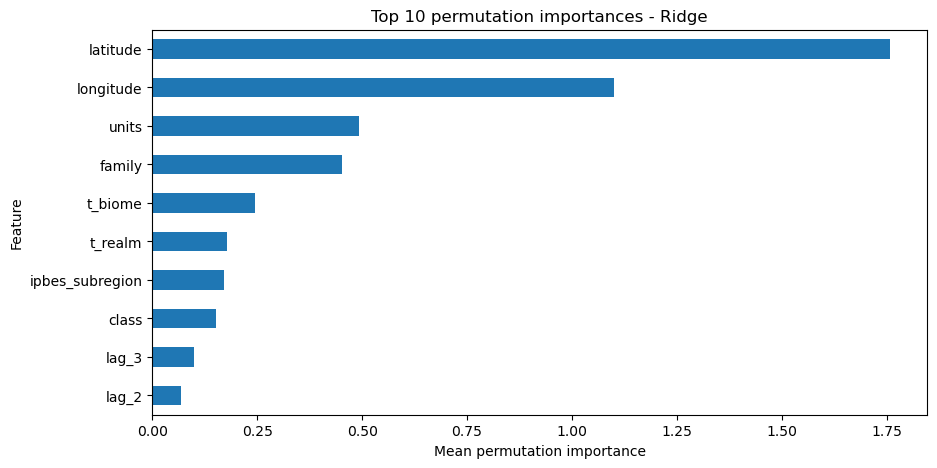

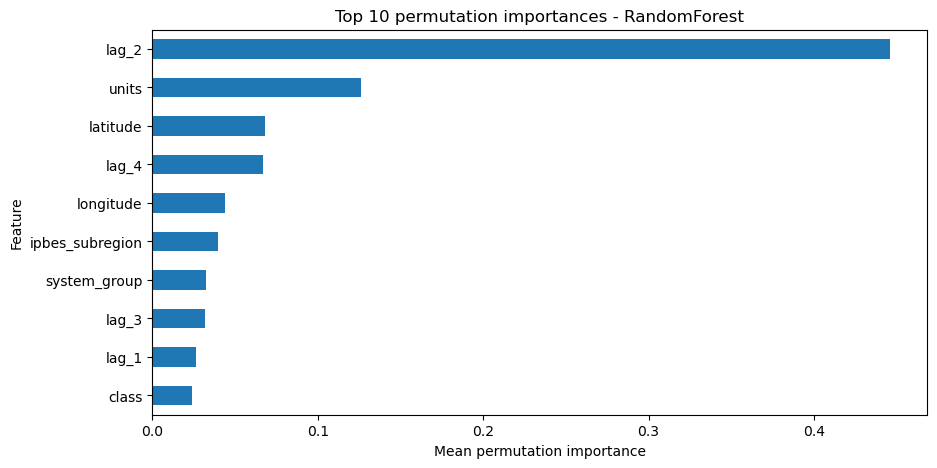

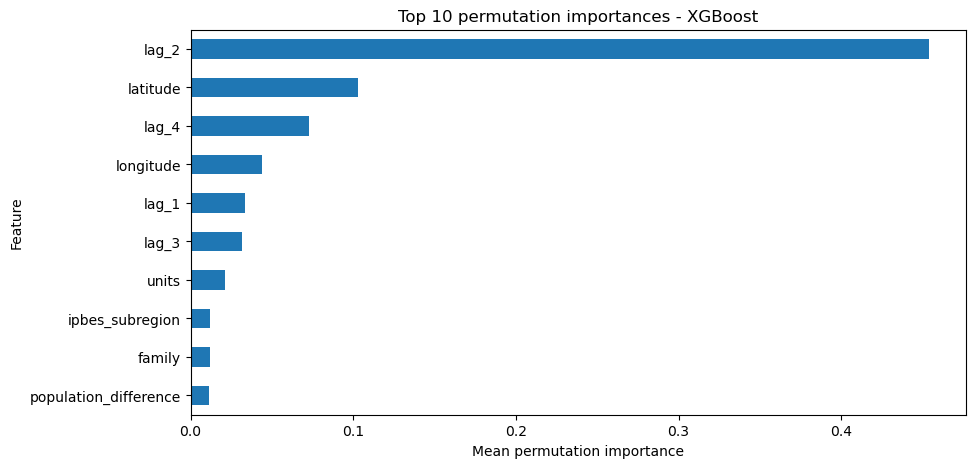

In [39]:
for model_name in importance_df["model"].unique():
    plot_df = (
        importance_df[importance_df["model"] == model_name]
        .groupby("feature")["importance_mean"]
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(10, 5))
    plot_df.sort_values().plot(kind="barh")
    plt.title(f"Top 10 permutation importances - {model_name}")
    plt.xlabel("Mean permutation importance")
    plt.ylabel("Feature")
    plt.show()

**Result summary:**  
The permutation importance results show that lag-based features - especially lag_2 - are by far the most influential predictors for both Random Forest and XGBoost, indicating that short-term population history is the primary driver of forecasting performance. Geographic features such as latitude and longitude also contribute meaningfully, suggesting that spatial context plays a secondary but relevant role. Additionally, categorical features like units and ecological classifications (e.g., IPBES subregion, system group) provide further explanatory power, although to a lesser extent. Overall, the results confirm that the models rely mainly on recent temporal dynamics, while environmental and taxonomic features help refine predictions across different species and regions.

This also indicates that further context data - like climate or population data - could provide additional explanatory power.

## 15. Best model per dataset

In [40]:
best_models = (
    results_df.sort_values(["dataset", "MAE"])
    .groupby("dataset", as_index=False)
    .first()
)

best_models

,dataset,dataset_group,model,best_params,MAE,RMSE,NMAE,WAPE,sMAPE,train_rows,test_rows,test_years
0,lpd_all_balanced_last2015_unitsusable_global_z...,balanced_forecasting,XGBoost,"{'model__learning_rate': 0.05, 'model__max_dep...",3.515299e+02,5.404696e+03,0.333723,0.333723,1.503669,29679,5540,"2016, 2017, 2018, 2019, 2020"
1,lpd_all_loose_last2010_unitsall_global_zeroske...,broad_exploration,RandomForest,"{'model__max_depth': None, 'model__n_estimator...",4.441607e+10,6.129489e+12,0.972105,0.972105,1.415350,176344,20010,"2016, 2017, 2018, 2019, 2020"
2,lpd_terrestrial_balanced_last2015_unitsusable_...,balanced_forecasting,XGBoost,"{'model__learning_rate': 0.05, 'model__max_dep...",2.614877e+02,9.817456e+02,0.304222,0.304222,1.081114,6574,989,"2016, 2017, 2018, 2019, 2020"
3,lpd_terrestrial_balanced_last2015_unitsusable_...,risk_decline,XGBoost,"{'model__learning_rate': 0.05, 'model__max_dep...",2.614877e+02,9.817456e+02,0.304222,0.304222,1.081114,6574,989,"2016, 2017, 2018, 2019, 2020"
4,lpd_terrestrial_balanced_last2015_unitsusable_...,geographic_subsets,XGBoost,"{'model__learning_rate': 0.05, 'model__max_dep...",3.108052e+02,1.406422e+03,0.360307,0.360307,1.110547,6514,978,"2016, 2017, 2018, 2019, 2020"
5,lpd_terrestrial_balanced_last2015_unitsusable_...,geographic_subsets,XGBoost,"{'model__learning_rate': 0.1, 'model__max_dept...",9.198082e+01,1.293914e+03,0.151275,0.151275,1.282706,4954,660,"2016, 2017, 2018, 2019, 2020"
6,lpd_terrestrial_loose_last2010_unitsall_global...,broad_exploration,RandomForest,"{'model__max_depth': None, 'model__n_estimator...",1.068813e+02,7.718813e+02,0.327818,0.327818,0.707906,84062,3158,"2016, 2017, 2018, 2019, 2020"
7,lpd_terrestrial_loose_last2015_unitsall_global...,risk_decline,RandomForest,"{'model__max_depth': None, 'model__n_estimator...",1.184117e+02,9.548494e+02,0.363184,0.363184,0.703285,17997,3158,"2016, 2017, 2018, 2019, 2020"
8,lpd_terrestrial_strict_last2020_unitsdirect_gl...,strict_forecasting,RandomForest,"{'model__max_depth': None, 'model__n_estimator...",7.513997e+00,1.891642e+01,0.151317,0.151317,0.712799,746,169,"2016, 2017, 2018, 2019, 2020"
9,lpd_terrestrial_strict_last2020_unitsusable_gl...,strict_forecasting,RandomForest,"{'model__max_depth': None, 'model__n_estimator...",5.418735e+00,1.491270e+01,0.156247,0.156247,0.907014,1065,244,"2016, 2017, 2018, 2019, 2020"


**Result summary:**  
This table identifies the best-performing model for each prepared dataset.  
It helps determine which dataset preparation strategy and which model are the strongest candidates for the next project step.

Since the two best performing datasets that use not only the top10countries (lpd_terrestrial_strict_last2020_unitsdirect_global_zeros_not_heavy.csv and lpd_terrestrial_strict_last2020_unitsusable_global_zeroskeep.csv) seem to perform best with the Random Forest model, this model should be considered as best choice at this moment.

## 16. Next steps

A natural next step is to transition from benchmarking to implementation by selecting one final dataset and one primary model based on the trade-off between performance and coverage. Building on this foundation, a separate notebook should be developed to focus on multi-step forecasting, extending the current one-step predictions to a longer horizon (e.g., 5–10 years). This includes implementing a suitable forecasting strategy and evaluating its performance over multiple future steps.